### John Felix C. Francisco | 2ECE-C
# Programming Assignment 3
#### IMPORTANT !!! Run this cell first for the other cells to work

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel('board2.xlsx')
tdf = df[['Math','Electronics','GEAS','Communication']]
means = pd.DataFrame(tdf.mean(axis=1), columns = ['Average'])
means 

df = pd.concat([df,means], axis=1)
df

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00
5,S6,Female,Microelectronics,Visayas,88,45,86,83,75.50
6,S7,Female,Instrumentation,Luzon,66,60,60,48,58.50
7,S8,Male,Instrumentation,Luzon,49,81,64,53,61.75
8,S9,Male,Instrumentation,Luzon,50,36,63,42,47.75
9,S10,Male,Microelectronics,Mindanao,80,84,61,44,67.25


## A. Visayas Communication Dataframe
##### Create a DataFrame named VisComm containing students whose Hometown is Visayas and whose Track is Communication. Retain only the Name, Gender, Math, Electronics, and Average columns

In [51]:
VisComm = df.loc[(df['Hometown'] == 'Visayas')&(df['Track'] == "Communication")]
display(VisComm[['Name','Gender','Math','Electronics','Average']]) 
print('Number of Rows:',len(VisComm))

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


Number of Rows: 5


## B. Visayas Female Dataframe
##### Create a second DataFrame named VisFemale containing students whose Hometown is Visayas and whose Gender is Female. Then display only the rows of VisFemale whose Average is at least 60 without overwriting VisFemale.

In [52]:
VisFemale = df.loc[(df['Hometown'] == 'Visayas')&(df['Gender'] == 'Female')]
VisFemale[['Name','Track','GEAS','Electronics','Average']]

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


In [53]:
VisFemale[['Name','Track','GEAS','Electronics','Average']].loc[(df['Average']>60)]

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


## C. Multi-Model Subsetting
##### Examine how the recorded Average differs across the three categorical features Track, Gender, and Hometown.

In [3]:
Track = df.groupby('Track')['Average'].mean().reset_index() 
Track

,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500


In [2]:
Gender = df.groupby('Gender')['Average'].mean().reset_index()
Gender

,Gender,Average
0,Female,66.616667
1,Male,67.183333


In [4]:
Hometown = df.groupby('Hometown')['Average'].mean().reset_index()
Hometown

,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


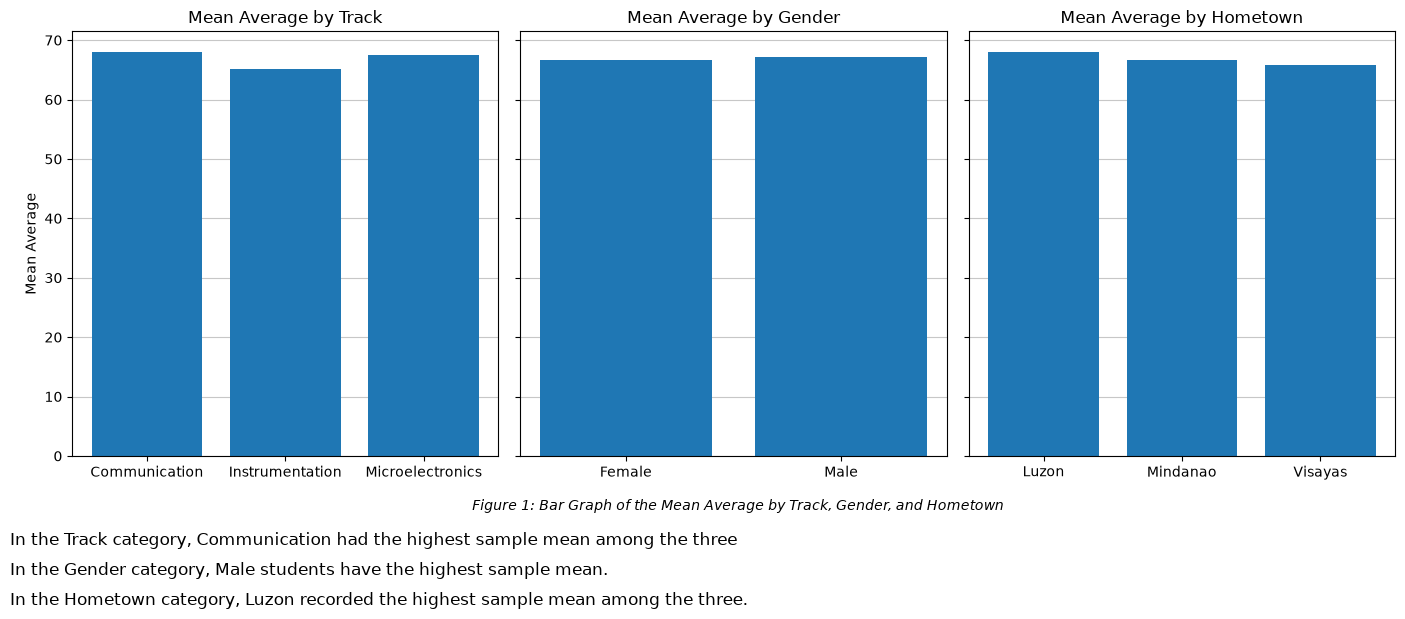

In [64]:
fig, axes = plt.subplots(nrows=1,ncols=3, figsize=(14,5), sharey=True)
fig.text(0.52,-0.03, 'Figure 1: Bar Graph of the Mean Average by Track, Gender, and Hometown', ha='center',style='italic')
fig.text(0,-0.1, 'In the Track category, Communication had the highest sample mean among the three.', fontsize=12) 
fig.text(0,-0.16, 'In the Gender category, Male students have the highest sample mean.', fontsize=12) 
fig.text(0,-0.22, 'In the Hometown category, Luzon recorded the highest sample mean among the three.', fontsize=12) 

axes[0].bar(Track['Track'], Track['Average'])
axes[0].set_title('Mean Average by Track')
axes[0].grid(axis='y',alpha=0.7)
axes[0].set_axisbelow(True)

axes[1].bar(Gender['Gender'],Gender['Average'])
axes[1].set_title('Mean Average by Gender')
axes[1].grid(axis='y',alpha=0.7)
axes[1].set_axisbelow(True)

axes[2].bar(Hometown['Hometown'],Hometown['Average'])
axes[2].set_title('Mean Average by Hometown')
axes[2].grid(axis='y',alpha=0.7)
axes[2].set_axisbelow(True)

axes[0].set_ylabel('Mean Average')
plt.tight_layout()
plt.show()

